In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Pull financial statements
ticker = yf.Ticker('LULU')
quarterly_income_statement = ticker.quarterly_income_stmt
quarterly_balance_sheet = ticker.quarterly_balance_sheet
annual_cash_flow = ticker.cash_flow

In [ ]:
# Balance sheet and cash flow inputs
cf = annual_cash_flow
if "Free Cash Flow" in cf.index:
    ltm_fcf = cf.loc["Free Cash Flow"].iloc[0]
else:
    ltm_fcf = cf.loc["Operating Cash Flow"].iloc[0] + cf.loc["Capital Expenditure"].iloc[0]

cash = quarterly_balance_sheet.loc["Cash Cash Equivalents And Short Term Investments", :].iloc[0]
total_debt = quarterly_balance_sheet.loc["Total Debt", :].iloc[0]
equity = ticker.info.get('marketCap')
tax_rate = 0.2  # Corp tax rate @ 20%
debt_equity_value = total_debt + equity

print(f"Base FCF:    ${ltm_fcf / 1e9:.2f}B")
print(f"Cash:        ${cash / 1e9:.2f}B")
print(f"Total Debt:  ${total_debt / 1e9:.2f}B")
print(f"Market Cap:  ${equity / 1e9:.2f}B")

Revenue projections, in usual cases, would be used to provide insight into a growth projection. However, considering the outliers from seasonal shopping during the holidays and liberation day, pulling from previous YOY balences will be more effective.

In [ ]:
# Growth Rate Assumption (Utilizing Average of Quarterly Revenue)
revenue = quarterly_income_statement.loc["Total Revenue"]
revenue_df = revenue.sort_index(ascending=True).to_frame()

revenue_df['Quarterly Growth Rate'] = revenue_df['Total Revenue'].pct_change()
revenue_df.dropna(inplace=True)
display(revenue_df)

projected_quarterly_growth = revenue_df['Quarterly Growth Rate'].mean()
projected_annual_growth = (1 + projected_quarterly_growth) ** 4 - 1

print(f"Projected Quarterly Growth: {projected_quarterly_growth * 100:.2f}%")
print(f"Projected Annual Growth: {projected_annual_growth * 100:.2f}%")


,Total Revenue,Quarterly Growth Rate
2024-10-31,2.396660e+09,0.010789
2025-01-31,3.611497e+09,0.506888
2025-04-30,2.370660e+09,-0.343580
2025-07-31,2.525219e+09,0.065197


Projected Quarterly Growth: 5.98%
Projected Annual Growth: 26.16%


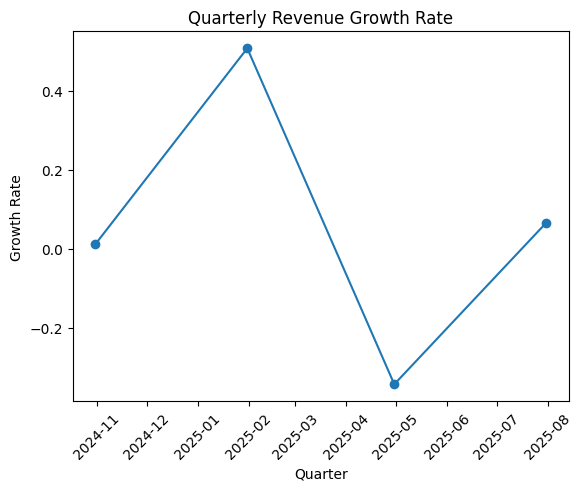

In [ ]:
plt.plot(revenue_df['Quarterly Growth Rate'], marker='o')
plt.title('Quarterly Revenue Growth Rate')
plt.xlabel('Quarter')
plt.ylabel('Growth Rate')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Cost of Equity via CAPM
risk_free_rate = 0.0414
market_return = 0.1
market_risk_premium = market_return - risk_free_rate
Cost_of_Equity = risk_free_rate + ticker.info.get('beta') * market_risk_premium

# LULU carries no traditional financial debt — Total Debt is entirely capital lease
# obligations (IFRS 16). Cost of debt approximated by incremental borrowing rate.
Cost_of_Debt = 0.045

print(f"Cost of Equity (CAPM): {Cost_of_Equity * 100:.2f}%")
print(f"Cost of Debt:          {Cost_of_Debt * 100:.2f}%")

In [ ]:
# WACC ((Equity/Equity + Debt * Cost of Equity) + (Debt/Equity+Debt * Cost of Debt * 1-tax rate))
WACC = ((equity/debt_equity_value) * Cost_of_Equity) + ((total_debt/debt_equity_value) * Cost_of_Debt * (1-tax_rate))
print(f"WACC: {WACC}")

WACC: 0.0966723474119961


In [ ]:
discount_rate = WACC
growth_rate = projected_annual_growth
terminal_growth = 0.02
assert discount_rate > terminal_growth, "Discount rate must be greater than terminal growth rate"
projection_years = 5

print(f"Discount Rate (WACC):  {discount_rate * 100:.2f}%")
print(f"FCF Growth Rate:       {growth_rate * 100:.2f}%")
print(f"Terminal Growth Rate:  {terminal_growth * 100:.2f}%")
print(f"Projection Years:      {projection_years}")

In [ ]:
fcf_projection = [ltm_fcf * (1 + growth_rate) ** i for i in range(1, projection_years + 1)]
discounted_fcfs = [fcf_projection[i] / (1 + discount_rate) ** (i + 1) for i in range(projection_years)]

discounted_fcf_table = pd.DataFrame({
    'Year': range(1, projection_years + 1),
    'Projected FCF ($)': [f"{v / 1e6:.1f}M" for v in fcf_projection],
    'Discounted FCF ($)': [f"{v / 1e6:.1f}M" for v in discounted_fcfs]
})
display(discounted_fcf_table)

# Terminal value (Gordon Growth Model)
terminal_value = fcf_projection[-1] * (1 + terminal_growth) / (discount_rate - terminal_growth)
terminal_value_discounted = terminal_value / (1 + discount_rate) ** projection_years

enterprise_value = sum(discounted_fcfs) + terminal_value_discounted
equity_value = enterprise_value + cash - total_debt

shares_outstanding = ticker.info["sharesOutstanding"]
dcf_price_per_share = equity_value / shares_outstanding
terminal_value_per_share = terminal_value_discounted / shares_outstanding

print(f"\nEnterprise Value:          ${enterprise_value / 1e9:.2f}B")
print(f"Equity Value:              ${equity_value / 1e9:.2f}B")
print(f"DCF Value Per Share:       ${dcf_price_per_share:.2f}")
print(f"Terminal Value/Share (PV): ${terminal_value_per_share:.2f}")

In [ ]:
# Current price vs DCF intrinsic value
current_price = ticker.info.get('currentPrice')
upside_pct = (dcf_price_per_share - current_price) / current_price * 100
margin_of_safety = (dcf_price_per_share - current_price) / dcf_price_per_share * 100

print("=" * 38)
print(f" Current Market Price:   ${current_price:.2f}")
print(f" DCF Intrinsic Value:    ${dcf_price_per_share:.2f}")
print(f" Upside / (Downside):    {upside_pct:+.1f}%")
print(f" Margin of Safety:       {margin_of_safety:.1f}%")
print("=" * 38)

# Visual bar chart: current price vs DCF
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Current Price', 'DCF Intrinsic Value'],
              [current_price, dcf_price_per_share],
              color=['#4C72B0', '#55A868'], edgecolor='black', width=0.4)
for bar, val in zip(bars, [current_price, dcf_price_per_share]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'${val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('LULU: Market Price vs DCF Intrinsic Value', fontsize=12)
ax.set_ylabel('Price per Share ($)')
ax.set_ylim(0, max(current_price, dcf_price_per_share) * 1.25)
plt.tight_layout()
plt.show()